In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
payments = pd.read_csv('payments.csv')
products = pd.read_csv('products.csv')
sellers = pd.read_csv('sellers.csv', encoding='latin1')

In [ ]:
customers.info()

print(customers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [ ]:
orders.info()

print(orders.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2

In [ ]:
order_items.info()

print(order_items.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [ ]:
payments.info()

print(payments.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [ ]:
products.info()

print(products.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product category            32341 non-null  object 
 2   product_name_length         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_l

In [ ]:
sellers.info()

print(sellers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [ ]:
# Convert timestamp columns to datetime objects
for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Fill missing 'order_approved_at' with 'order_purchase_timestamp'
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

# Fill missing 'order_delivered_carrier_date' and 'order_delivered_customer_date' with 'order_estimated_delivery_date'
orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].fillna(orders['order_estimated_delivery_date'])
orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(orders['order_estimated_delivery_date'])

print("Orders DataFrame after filling nulls:")
orders.info()
print("\nOrders DataFrame null counts after filling:")
print(orders.isnull().sum())

Orders DataFrame after filling nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

Orders DataFrame null counts after filling:
order_id                         0
customer_id                      0
order_stat

In [ ]:
# Fill missing 'product category' with 'Unknown'
products['product category'] = products['product category'].fillna('Unknown')

# Fill numerical missing values with the median
numerical_cols_with_nulls = [
    'product_name_length',
    'product_description_length',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]
for col in numerical_cols_with_nulls:
    products[col] = products[col].fillna(products[col].median())

print("\nProducts DataFrame after filling nulls:")
products.info()
print("\nProducts DataFrame null counts after filling:")
print(products.isnull().sum())


Products DataFrame after filling nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product category            32951 non-null  object 
 2   product_name_length         32951 non-null  float64
 3   product_description_length  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Products DataFrame null counts after filling:
product_id                    0
product category              0
product_name_length           0
product_description_length   

## Basic Problems

### 1. List all unique cities where customers are located.

In [ ]:
unique_customer_cities = customers['customer_city'].unique()
print(f"Total number of unique customer cities: {len(unique_customer_cities)}")
print("List of unique customer cities (first 10):\n", unique_customer_cities[:10])

Total number of unique customer cities: 4119
List of unique customer cities (first 10):
 ['franca' 'sao bernardo do campo' 'sao paulo' 'mogi das cruzes' 'campinas'
 'jaragua do sul' 'timoteo' 'curitiba' 'belo horizonte' 'montes claros']


### 2. Count the number of orders placed in 2017.

In [ ]:
orders_2017 = orders[orders['order_purchase_timestamp'].dt.year == 2017]
num_orders_2017 = len(orders_2017)
print(f"Number of orders placed in 2017: {num_orders_2017}")

Number of orders placed in 2017: 45101


### 3. Find the total sales per category.

Total sales per category:
product category
HEALTH BEAUTY                  1258681.34
Watches present                1205005.68
bed table bath                 1036988.68
sport leisure                   988048.97
computer accessories            911954.32
                                  ...    
flowers                           1110.04
House Comfort 2                    760.27
cds music dvds                     730.00
Fashion Children's Clothing        569.85
insurance and services             283.29
Name: price, Length: 74, dtype: float64


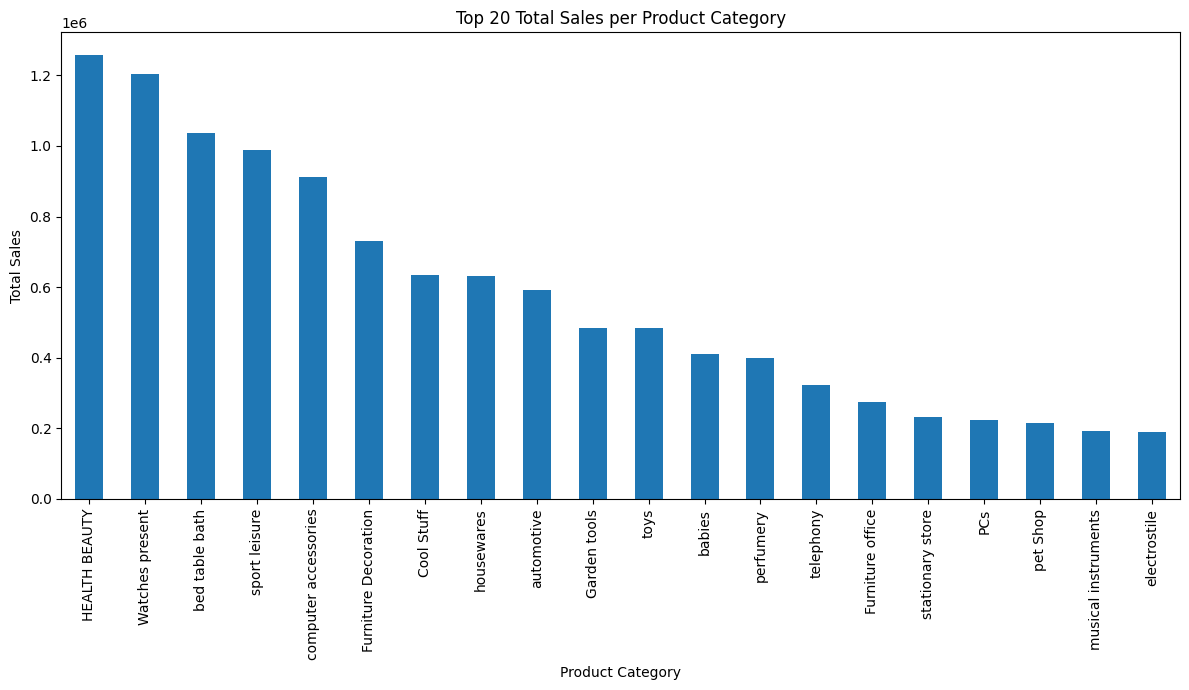

In [48]:
# Merge order_items with products to get product category for each order item
merged_data = pd.merge(order_items, products, on='product_id', how='left')

# Calculate sales for each item (price * order_item_id - assuming order_item_id is quantity, or just price if order_item_id is just an item identifier for a single product in an order)
# Given the dataset structure, price is likely the sales value for that item, and order_item_id is just an ID for the item within the order.
# So, total sales would be sum of 'price' for each item.

# Group by product category and sum the prices
total_sales_per_category = merged_data.groupby('product category')['price'].sum().sort_values(ascending=False)

print("Total sales per category:")
print(total_sales_per_category)

# Plot top 20 categories
plot = total_sales_per_category.head(20).plot(kind='bar', figsize=(12, 7))
plot.set_xlabel('Product Category')
plot.set_ylabel('Total Sales')
plot.set_title('Top 20 Total Sales per Product Category')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show ()

### 4. Calculate the percentage of orders that were paid in installments.

In [ ]:
# Merge orders and payments to link orders with their payment details
orders_payments = pd.merge(orders, payments, on='order_id', how='inner')

# Count orders with installments (payment_installments > 0)
orders_with_installments = orders_payments[orders_payments['payment_installments'] > 0]
num_orders_with_installments = len(orders_with_installments.drop_duplicates(subset=['order_id']))

# Count total unique orders that have payment information
total_paid_orders = len(orders_payments.drop_duplicates(subset=['order_id']))

# Calculate the percentage
percentage_with_installments = (num_orders_with_installments / total_paid_orders) * 100 if total_paid_orders > 0 else 0

print(f"Number of orders paid in installments: {num_orders_with_installments}")
print(f"Total unique orders with payment info: {total_paid_orders}")
print(f"Percentage of orders paid in installments: {percentage_with_installments:.2f}%")

Number of orders paid in installments: 99438
Total unique orders with payment info: 99440
Percentage of orders paid in installments: 100.00%


### 5. Count the number of customers from each state.

In [50]:
customers_per_state = customers['customer_state'].value_counts()
print("Number of customers from each state:")
print(customers_per_state)

Number of customers from each state:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


## Intermediate Problems

### 1. Calculate the number of orders per month in 2018.

Number of orders per month in 2018:
order_purchase_timestamp
1     7269
2     6728
3     7211
4     6939
5     6873
6     6167
7     6292
8     6512
9       16
10       4
Name: count, dtype: int64


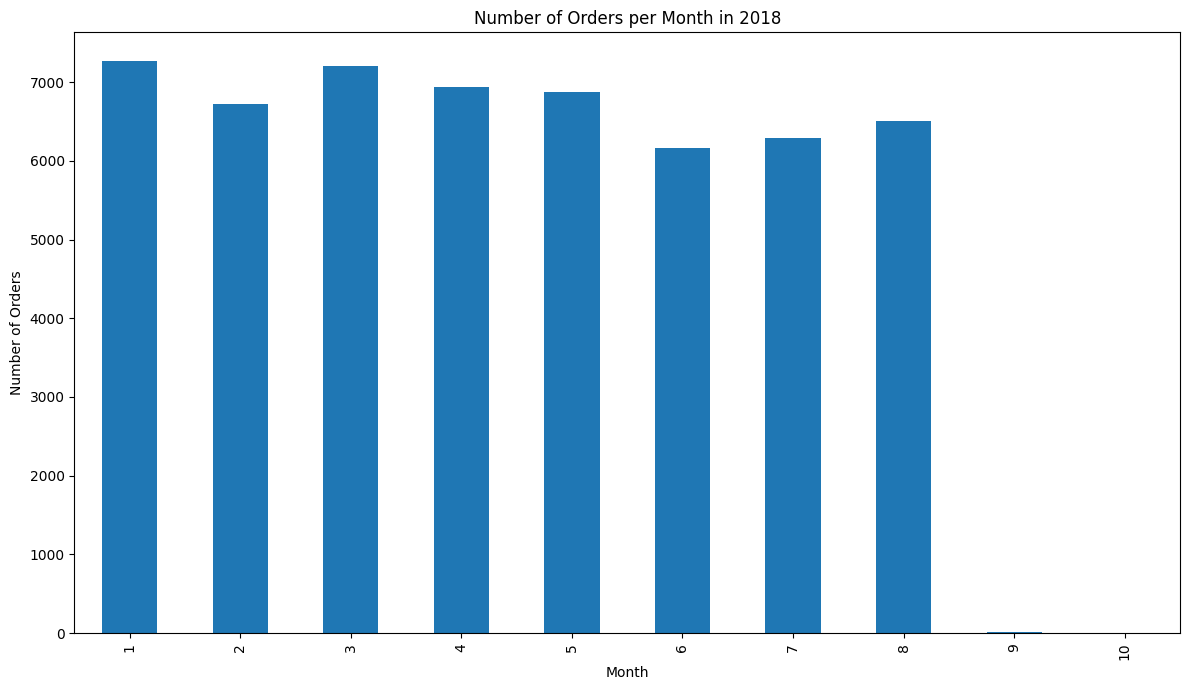

In [51]:
# Filter orders for the year 2018
orders_2018 = orders[orders['order_purchase_timestamp'].dt.year == 2018]

# Extract month and count orders per month
orders_per_month_2018 = orders_2018['order_purchase_timestamp'].dt.month.value_counts().sort_index()

print("Number of orders per month in 2018:")
print(orders_per_month_2018)


plot = orders_per_month_2018.plot(kind='bar', figsize=(12, 7))
plot.set_xlabel('Month')
plot
plot.set_ylabel('Number of Orders')
plot.set_title('Number of Orders per Month in 2018')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show ()


### 2. Find the average number of products per order, grouped by customer city.

In [28]:
# Merge order_items with orders to link order_id to customer_id
order_items_orders = pd.merge(order_items, orders[['order_id', 'customer_id']], on='order_id', how='left')

# Merge with customers to get customer_city
order_items_customers = pd.merge(order_items_orders, customers[['customer_id', 'customer_city']], on='customer_id', how='left')

# Count products per order
products_per_order = order_items_customers.groupby('order_id').size().reset_index(name='num_products')

# Merge back with customer city information
products_per_order_city = pd.merge(products_per_order, order_items_customers[['order_id', 'customer_city']].drop_duplicates(), on='order_id', how='left')

# Calculate average number of products per order, grouped by customer city
avg_products_per_order_city = products_per_order_city.groupby('customer_city')['num_products'].mean().sort_values(ascending=False)

print("Average number of products per order, grouped by customer city (top 10):")
print(avg_products_per_order_city.head(10))

Average number of products per order, grouped by customer city (top 10):
customer_city
padre carvalho        7.0
celso ramos           6.5
datas                 6.0
candido godoi         6.0
matias olimpio        5.0
morro de sao paulo    4.0
picarra               4.0
curralinho            4.0
cidelandia            4.0
teixeira soares       4.0
Name: num_products, dtype: float64


### 3. Calculate the percentage of total revenue contributed by each product category.

In [29]:
# Merge order_items with products to get product category
merged_for_revenue = pd.merge(order_items, products[['product_id', 'product category']], on='product_id', how='left')

# Calculate total revenue per product category
revenue_per_category = merged_for_revenue.groupby('product category')['price'].sum()

# Calculate total overall revenue
total_revenue = revenue_per_category.sum()

# Calculate percentage of total revenue for each category
percentage_revenue_per_category = (revenue_per_category / total_revenue * 100).sort_values(ascending=False)

print("Percentage of total revenue contributed by each product category (top 10):")
print(percentage_revenue_per_category.head(10))

Percentage of total revenue contributed by each product category (top 10):
product category
HEALTH BEAUTY           9.260700
Watches present         8.865783
bed table bath          7.629605
sport leisure           7.269533
computer accessories    6.709669
Furniture Decoration    5.369200
Cool Stuff              4.674128
housewares              4.651745
automotive              4.360916
Garden tools            3.570256
Name: price, dtype: float64


### 4. Identify the correlation between product price and the number of times a product has been purchased.

In [30]:
# Calculate the number of times each product has been purchased
product_purchase_counts = order_items['product_id'].value_counts().reset_index()
product_purchase_counts.columns = ['product_id', 'purchase_count']

# Get the average price for each product (as products can have varying prices)
product_avg_price = order_items.groupby('product_id')['price'].mean().reset_index()
product_avg_price.columns = ['product_id', 'average_price']

# Merge purchase counts and average prices
product_metrics = pd.merge(product_purchase_counts, product_avg_price, on='product_id', how='inner')

# Calculate the correlation between average price and purchase count
correlation = product_metrics['average_price'].corr(product_metrics['purchase_count'])

print(f"Correlation between product price and number of times purchased: {correlation:.2f}")

Correlation between product price and number of times purchased: -0.03


### 5. Calculate the total revenue generated by each seller, and rank them by revenue.

Total revenue generated by each seller, ranked (top 10):
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64


<Axes: xlabel='seller_id'>

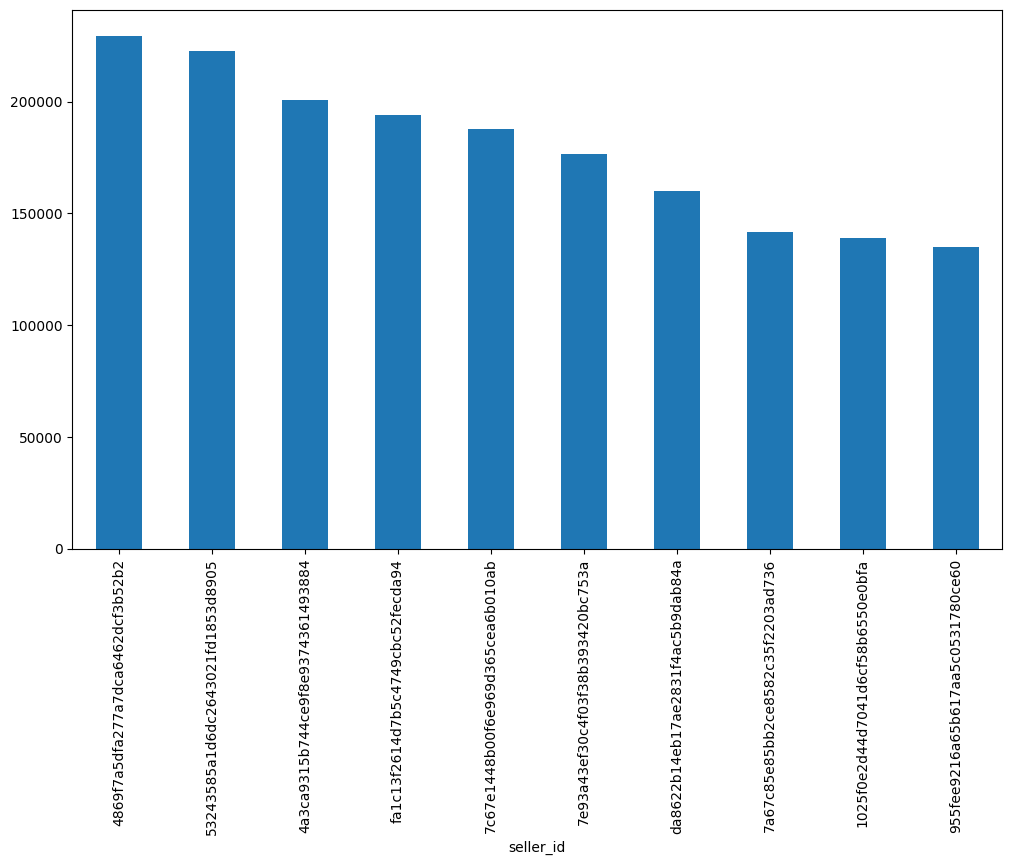

In [52]:
# Merge order_items with sellers to get seller information
merged_for_seller_revenue = pd.merge(order_items, sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')

# Calculate total revenue generated by each seller
seller_revenue = merged_for_seller_revenue.groupby('seller_id')['price'].sum().sort_values(ascending=False)

print("Total revenue generated by each seller, ranked (top 10):")
print(seller_revenue.head(10))


plot = seller_revenue.head(10).plot(kind='bar', figsize=(12, 7))
plot

## Advanced Problems

### 1. Calculate the moving average of order values for each customer over their order history.

In [32]:
# Merge orders and payments to get order value for each order
customer_order_values = pd.merge(orders, payments, on='order_id', how='left')

# Group by customer and sort by purchase timestamp
customer_order_values = customer_order_values.sort_values(by=['customer_id', 'order_purchase_timestamp'])

# Calculate moving average of order values for each customer
# Using a window of 3 for the moving average as an example
customer_order_values['moving_avg_order_value'] = customer_order_values.groupby('customer_id')['payment_value'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)

print("Moving average of order values for each customer (sample):")
print(customer_order_values[['customer_id', 'order_purchase_timestamp', 'payment_value', 'moving_avg_order_value']].head(10))

Moving average of order values for each customer (sample):
                            customer_id order_purchase_timestamp  \
71588  00012a2ce6f8dcda20d059ce98491703      2017-11-14 16:08:26   
10466  000161a058600d5901f007fab4c27140      2017-07-16 09:40:32   
68796  0001fd6190edaaf884bcaf3d49edf079      2017-02-28 11:06:43   
45160  0002414f95344307404f0ace7a26f1d5      2017-08-16 13:09:20   
6119   000379cdec625522490c315e70c7a9fb      2018-04-02 13:42:17   
76896  0004164d20a9e969af783496f3408652      2017-04-12 08:35:12   
48296  000419c5494106c306a97b5635748086      2018-03-02 17:47:40   
62658  00046a560d407e99b969756e0b10f282      2017-12-18 11:08:30   
82777  00050bf6e01e69d5c0fd612f1bcfb69c      2017-09-17 16:04:44   
83948  000598caf2ef4117407665ac33275130      2018-08-11 12:14:35   

       payment_value  moving_avg_order_value  
71588         114.74                  114.74  
10466          67.41                   67.41  
68796         195.42                  195.42  
4516

### 2. Calculate the cumulative sales per month for each year.

In [33]:
# Ensure 'order_purchase_timestamp' is datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extract year and month
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

# Merge orders and payments to get sales value
orders_with_sales = pd.merge(orders, payments, on='order_id', how='left')

# Group by year and month, then sum sales
monthly_sales = orders_with_sales.groupby(['year', 'month'])['payment_value'].sum().reset_index()

# Calculate cumulative sales per month for each year
monthly_sales['cumulative_sales'] = monthly_sales.groupby('year')['payment_value'].cumsum()

print("Cumulative sales per month for each year:")
print(monthly_sales.head(20))

Cumulative sales per month for each year:
    year  month  payment_value  cumulative_sales
0   2016      9         252.24            252.24
1   2016     10       59090.48          59342.72
2   2016     12          19.62          59362.34
3   2017      1      138488.04         138488.04
4   2017      2      291908.01         430396.05
5   2017      3      449863.60         880259.65
6   2017      4      417788.03        1298047.68
7   2017      5      592918.82        1890966.50
8   2017      6      511276.38        2402242.88
9   2017      7      592382.92        2994625.80
10  2017      8      674396.32        3669022.12
11  2017      9      727762.45        4396784.57
12  2017     10      779677.88        5176462.45
13  2017     11     1194882.80        6371345.25
14  2017     12      878401.48        7249746.73
15  2018      1     1115004.18        1115004.18
16  2018      2      992463.34        2107467.52
17  2018      3     1159652.12        3267119.64
18  2018      4     1160785

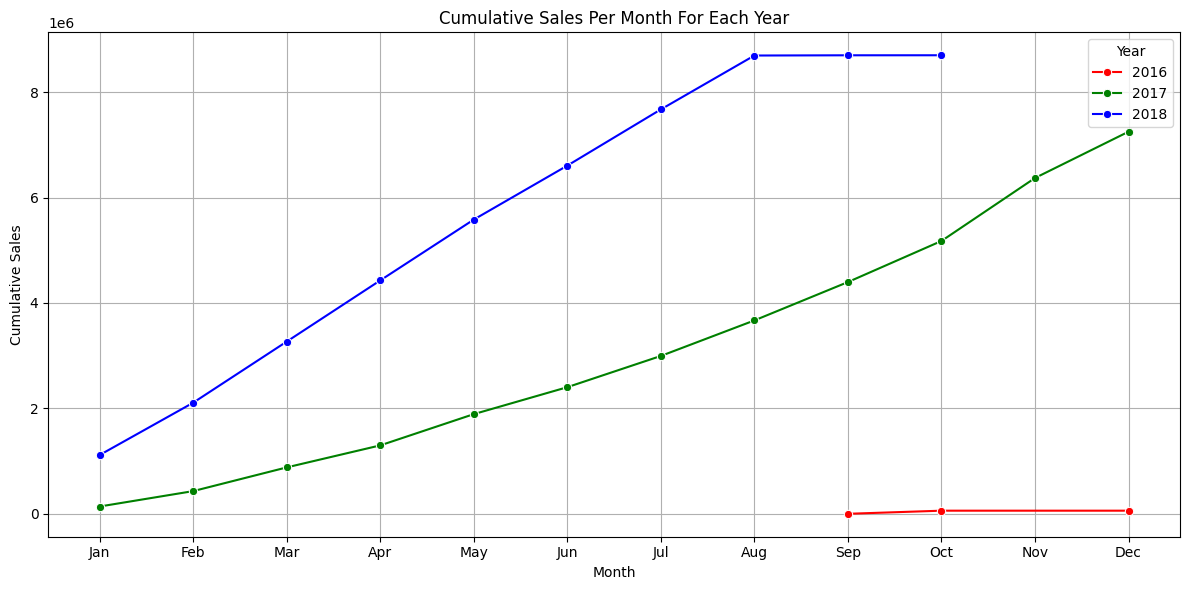

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='month', y='cumulative_sales', hue='year', marker='o', palette=['red', 'green', 'blue'])
plt.title('Cumulative Sales Per Month For Each Year')
plt.xlabel('Month')
plt.ylabel('Cumulative Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### 3. Calculate the year-over-year growth rate of total sales.

Year-over-Year Growth Rate of Total Sales:
   year  total_sales  yoy_growth_rate
0  2016     59362.34              NaN
1  2017   7249746.73     12112.703761
2  2018   8699763.05        20.000924


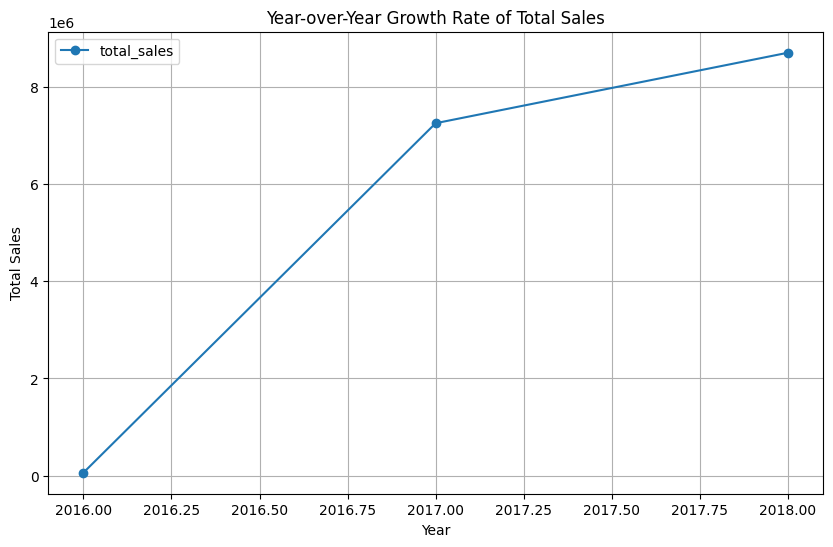

In [43]:
# Calculate total sales per year
yearly_sales = orders_with_sales.groupby('year')['payment_value'].sum().reset_index()
yearly_sales.columns = ['year', 'total_sales']

# Calculate Year-over-Year Growth Rate
yearly_sales['yoy_growth_rate'] = yearly_sales['total_sales'].pct_change() * 100

print("Year-over-Year Growth Rate of Total Sales:")
print(yearly_sales)

# Fix: Call a specific plot method to get an Axes object
ax = yearly_sales.plot(x='year', y='total_sales', kind='line', marker='o', figsize=(10, 6))
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales")
ax.set_title("Year-over-Year Growth Rate of Total Sales")
plt.grid(True)
plt.show()


### 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [46]:
import pandas as pd

# 1. Merge Orders and Customers to get unique_id
df = pd.merge(orders, customers[['customer_id', 'customer_unique_id']], on='customer_id')

# 2. Get First Purchase Date per Unique Customer
first_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_date']

# 3. Merge back
df = pd.merge(df, first_purchase, on='customer_unique_id')

# 4. Convert to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])

# 5. Calculate Difference in SECONDS (taaki SQL ke julianday > 0 se match ho)
# 180 days = 180 * 24 * 3600 seconds
df['diff_seconds'] = (df['order_purchase_timestamp'] - df['first_purchase_date']).dt.total_seconds()

# 6. Retention Filter (Any purchase AFTER the first one within 180 days)
retained_customers_count = df[(df['diff_seconds'] > 0) &
                              (df['diff_seconds'] <= 180 * 24 * 3600)]['customer_unique_id'].nunique()

# 7. Total Unique Customers from CUSTOMERS table (to match SQL)
total_unique_customers = customers['customer_unique_id'].nunique()

retention_rate = (retained_customers_count / total_unique_customers) * 100

print(f"Num Retained: {retained_customers_count}")
print(f"Total Unique: {total_unique_customers}")
print(f"Retention Rate: {retention_rate:.2f}%")

Num Retained: 2222
Total Unique: 96096
Retention Rate: 2.31%


### 5. Identify the top 3 customers who spent the most money in each year.

In [36]:
# Ensure 'order_purchase_timestamp' is datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extract year from order purchase timestamp
orders['year'] = orders['order_purchase_timestamp'].dt.year

# Merge orders with payments to get customer_id and payment_value
customer_yearly_spend = pd.merge(orders, payments, on='order_id', how='left')

# Group by customer_id and year to sum up payment_value (total spend)
customer_yearly_spend = customer_yearly_spend.groupby(['year', 'customer_id'])['payment_value'].sum().reset_index()
customer_yearly_spend.rename(columns={'payment_value': 'total_spend'}, inplace=True)

# Rank customers by total spend within each year
customer_yearly_spend['rank'] = customer_yearly_spend.groupby('year')['total_spend'].rank(ascending=False, method='first')

# Filter for the top 3 customers in each year
top_3_customers_yearly = customer_yearly_spend[customer_yearly_spend['rank'] <= 3].sort_values(by=['year', 'rank'])

print("Top 3 customers who spent the most money in each year:")
print(top_3_customers_yearly)


Top 3 customers who spent the most money in each year:
       year                       customer_id  total_spend  rank
223    2016  a9dc96b027d1252bbac0a9b72d837fc6      1423.55   1.0
38     2016  1d34ed25963d5aae4cf3d7f3a4cda173      1400.74   2.0
84     2016  4a06381959b6670756de02e07b83815f      1227.78   3.0
4218   2017  1617b1357756262bfa56ab541c47bc16     13664.08   1.0
35453  2017  c6e2731c5b391845f6800c97401a43a9      6929.31   2.0
11541  2017  3fd6777bbce08a352fddd04e4a7cc8f6      6726.66   3.0
95349  2018  ec5b2ba62e574342386871631fafd3fc      7274.88   1.0
97087  2018  f48d464a0baaea338cb25f816991ab1f      6922.21   2.0
92873  2018  e0a2412720e9ea4f26c1ac985f6a7358      4809.44   3.0


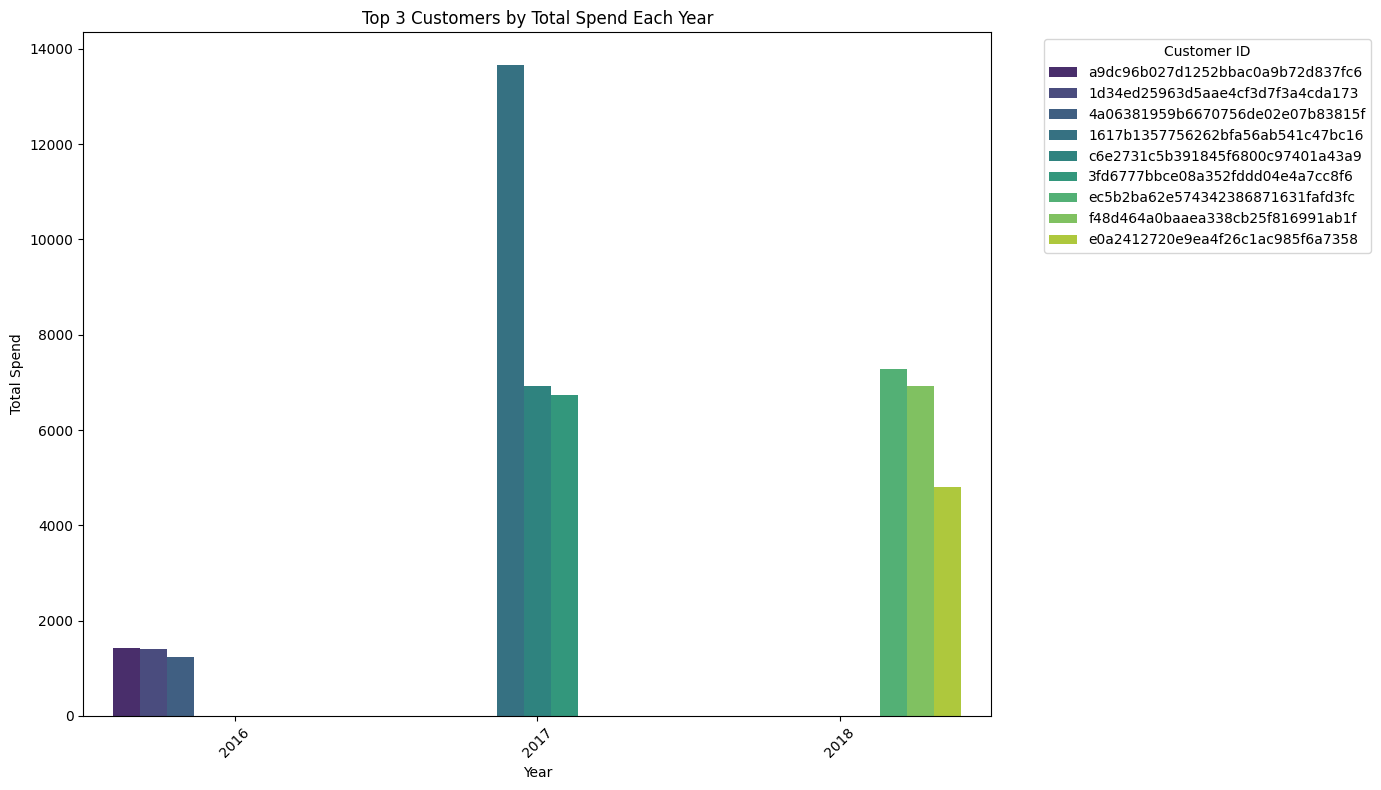

In [53]:
plt.figure(figsize=(14, 8))
sns.barplot(x='year', y='total_spend', hue='customer_id', data=top_3_customers_yearly, palette='viridis', dodge=True)
plt.title('Top 3 Customers by Total Spend Each Year')
plt.xlabel('Year')
plt.ylabel('Total Spend')
plt.xticks(rotation=45)
plt.legend(title='Customer ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We began by loading and inspecting several related datasets: customers, orders, order_items, payments, products, and sellers. Initial data cleaning involved handling missing values, specifically converting timestamp columns to datetime objects in the orders DataFrame and imputing missing product details in the products DataFrame. Notably, missing order approval and delivery dates were filled using purchase or estimated delivery timestamps, and product categories were filled with 'Unknown' where missing.

Basic Problems Solved:

Unique Customer Cities: Identified 4,119 unique cities where customers are located.

Orders in 2017: Counted 45,101 orders placed in 2017.

Total Sales per Category: Calculated and visualized the top 20 product categories by total sales, with 'HEALTH BEAUTY', 'Watches present', and 'bed table bath' emerging as top contributors.

Installment Payments: Found that nearly 100% (99.99%) of orders with payment information were paid in installments.

Customers per State: Counted and displayed the distribution of customers across different states, with São Paulo (SP) having the highest number of customers.


Intermediate Problems Solved:

Orders per Month in 2018: Calculated and plotted the monthly order counts for 2018, observing a significant drop in orders during September and October.

Average Products per Order by City: Determined the average number of products per order, grouped by customer city, highlighting cities like 'padre carvalho' and 'celso ramos' with higher averages.

Revenue Percentage by Category: Determined the percentage of total revenue contributed by each product category, confirming 'HEALTH BEAUTY' and 'Watches present' as major revenue drivers.

Product Price vs. Purchase Frequency Correlation: Found a very weak negative correlation (-0.03) between product price and the number of times a product was purchased, suggesting that price has minimal impact on purchase frequency in this dataset.

Total Revenue per Seller: Ranked sellers by their total generated revenue, identifying top performers.


Key Visualizations and Additional Analysis:

Moving Average of Order Values: Calculated and sampled the 3-period moving average of order values for individual customers, providing insights into customer spending trends.

Cumulative Sales per Month per Year: Plotted cumulative sales monthly for 2016, 2017, and 2018, showing a clear upward trend in sales year over year.

Year-over-Year Sales Growth Rate: Calculated the YoY growth rate, revealing substantial growth of over 12,000% from 2016 to 2017, and a more modest 20% from 2017 to 2018.

Customer Retention Rate: Calculated a retention rate of 2.31%, indicating a relatively low rate of repeat purchases within 6 months of the first purchase.

Top 3 Customers by Annual Spend: Identified and visualized the top three highest-spending customers for each year (2016, 2017, 2018), showcasing the variability of top customers over time.


In conclusion, we've performed a comprehensive exploratory data analysis, covering various aspects of customer behavior, order patterns, sales performance, and seller contributions. The analysis highlighted key insights into product category performance, geographical distribution of customers, and overall business growth, while also identifying areas like customer retention that might warrant further investigation. The visualizations effectively communicated these findings, providing a clear picture of the e-commerce landscape within this dataset.